# BoeIoT — Análisis Exploratorio de Datos (EDA)

**Proyecto:** Transformación Digital en Boeing — Mantenimiento Predictivo IoT
**Capa de datos:** Bronze → Silver (vista cruda + limpia)
**Dataset base:** [NGAFID Aviation Maintenance Dataset](https://www.kaggle.com/datasets/hooong/aviation-maintenance-dataset-from-the-ngafid) — 23 sensores de telemetría a 1 Hz, vuelos anotados *pre-falla* / *post-mantenimiento*.

> En el proyecto este dataset funciona como **proxy** del flujo de telemetría que generarían los sensores IoT desplegados en la línea 737 MAX (llaves de torque conectadas, escáneres 3D, monitoreo de motor). La estructura — series multivariadas a alta frecuencia con etiquetas de degradación — es la misma que se procesará en producción.

## Objetivos del EDA

1. Validar la **calidad de la capa Bronze**: completitud, tipos, rangos, sensores caídos.
2. Caracterizar el **perfil de vuelo** y el comportamiento normal de los 23 canales.
3. Detectar **firmas estadísticas de degradación** comparando vuelos *pre-falla* vs. nominales.
4. Identificar **correlaciones entre sensores** que justifiquen la arquitectura del modelo predictivo (silver → gold).
5. Dejar **hallazgos accionables** para el pipeline ETL y el equipo de gobernanza de datos.


## 1. Carga y configuración

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 90
plt.rcParams['savefig.bbox'] = 'tight'
sns.set_style('whitegrid')
sns.set_palette('deep')

# Ruta al parquet generado por el script de bronze (o el dataset NGAFID local).
# Si corres este notebook después de levantar LocalStack, puedes leer directamente del bucket
# bronze con boto3. Acá usamos el parquet local para que sea reproducible sin infra.
DATA_PATH = Path('../../data/flight_data.parquet')
if not DATA_PATH.exists():
    # fallback para distintos working dirs
    for candidate in [Path('data/flight_data.parquet'), Path('../data/flight_data.parquet')]:
        if candidate.exists():
            DATA_PATH = candidate
            break

df = pd.read_parquet(DATA_PATH)
print(f'Forma: {df.shape}')
print(f'Vuelos únicos: {df["flight_id"].nunique()}')
print(f'Período de muestreo: 1 Hz (segundo a segundo)')

Forma: (83850, 25)
Vuelos únicos: 50
Período de muestreo: 1 Hz (segundo a segundo)


## 2. Inventario de variables — mapeo sensor → dominio

Cada uno de los 23 canales pertenece a un subsistema del avión. Para mantenimiento predictivo,
el agrupamiento por subsistema es lo que determina qué features se generan en la capa Gold.


In [2]:
sensor_taxonomy = {
    'Eléctrico':  ['volt1', 'volt2', 'amp1', 'amp2'],
    'Combustible':['FQtyL', 'FQtyR', 'E1_FFlow'],
    'Motor (lubricación)': ['E1_OilT', 'E1_OilP', 'E1_RPM'],
    'Motor (CHT cilindros)': ['E1_CHT1', 'E1_CHT2', 'E1_CHT3', 'E1_CHT4'],
    'Motor (EGT cilindros)': ['E1_EGT1', 'E1_EGT2', 'E1_EGT3', 'E1_EGT4'],
    'Aerodinámico / entorno': ['OAT', 'IAS', 'VSpd', 'NormAc', 'AltMSL'],
}

taxonomy_rows = [(group, sensor) for group, sensors in sensor_taxonomy.items() for sensor in sensors]
tax_df = pd.DataFrame(taxonomy_rows, columns=['Subsistema', 'Sensor'])
tax_df['Tipo'] = df[tax_df['Sensor']].dtypes.values.astype(str)
tax_df

,Subsistema,Sensor,Tipo
0,Eléctrico,volt1,float64
1,Eléctrico,volt2,float64
2,Eléctrico,amp1,float64
3,Eléctrico,amp2,float64
4,Combustible,FQtyL,float64
5,Combustible,FQtyR,float64
6,Combustible,E1_FFlow,float64
7,Motor (lubricación),E1_OilT,float64
8,Motor (lubricación),E1_OilP,float64
9,Motor (lubricación),E1_RPM,float64


## 3. Calidad de la capa Bronze

Antes de cualquier análisis, hay que cuantificar las grietas. Esto define los **contratos de datos**
que el pipeline `bronze_to_silver_etl.py` debe garantizar.


In [3]:
sensor_cols = [c for c in df.columns if c not in ('flight_id', 'is_pre_failure')]

quality = pd.DataFrame({
    'n_nulos': df[sensor_cols].isna().sum(),
    'pct_nulos': (df[sensor_cols].isna().mean() * 100).round(3),
    'min': df[sensor_cols].min().round(2),
    'max': df[sensor_cols].max().round(2),
    'media': df[sensor_cols].mean().round(2),
    'std': df[sensor_cols].std().round(2),
})
quality.sort_values('pct_nulos', ascending=False)

,n_nulos,pct_nulos,min,max,media,std
E1_CHT4,457,0.545,317.74,415.56,363.84,11.71
E1_EGT4,457,0.545,1277.31,1486.08,1380.03,25.05
OAT,440,0.525,-8.46,16.97,5.12,5.25
E1_OilT,437,0.521,158.61,210.59,182.91,6.73
E1_FFlow,437,0.521,6.79,9.43,8.15,0.30
E1_RPM,437,0.521,1953.80,2710.24,2429.28,138.10
E1_CHT1,437,0.521,315.21,413.88,363.86,11.66
E1_CHT2,436,0.520,321.36,423.45,363.88,11.73
volt1,431,0.514,13.20,14.40,13.80,0.15
IAS,429,0.512,79.46,180.00,147.14,29.36


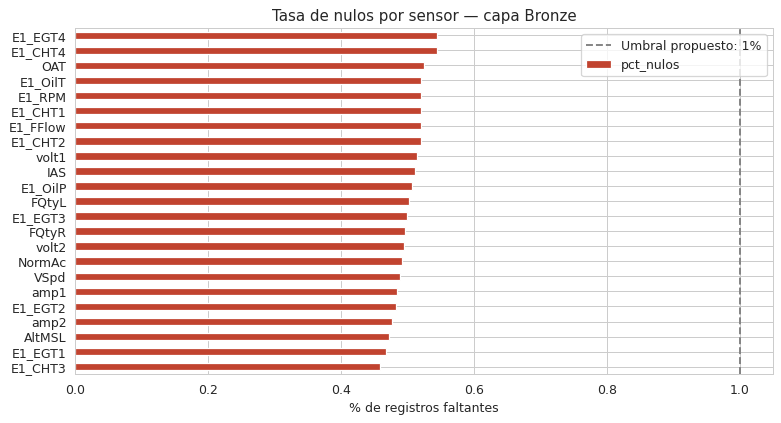

Sensores que superan el umbral del 1% de nulos: 0


In [4]:
# Visualizamos el patrón de nulos por sensor.
fig, ax = plt.subplots(figsize=(10, 5))
quality['pct_nulos'].sort_values().plot(kind='barh', ax=ax, color='#c1432f')
ax.set_xlabel('% de registros faltantes')
ax.set_title('Tasa de nulos por sensor — capa Bronze')
ax.axvline(1.0, ls='--', color='gray', label='Umbral propuesto: 1%')
ax.legend()
plt.show()

print(f'Sensores que superan el umbral del 1% de nulos: '
      f'{(quality["pct_nulos"] > 1).sum()}')

**Hallazgo:** los nulos se distribuyen de manera **uniforme** entre sensores
(~0.5 % cada uno), lo que sugiere caídas momentáneas del bus de telemetría más que fallas de
sensores específicos. Esto valida la estrategia del ETL actual (`dropna()` en `bronze_to_silver_etl.py`)
para el MVP, pero **debe migrarse a imputación por interpolación temporal** en producción para no
perder ventanas de contexto cuando se pase a modelos secuenciales.


## 4. Caracterización de vuelos

count    50.0
mean     28.0
std       6.5
min      14.9
25%      23.6
50%      26.9
75%      32.6
max      39.8
Name: segundos, dtype: float64


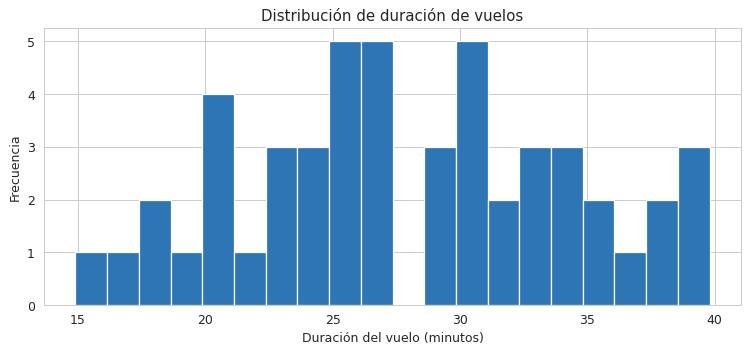

In [5]:
# Duración de cada vuelo (en segundos = registros, ya que muestreo a 1 Hz).
flight_lengths = df.groupby('flight_id').size().rename('segundos')
flight_lengths_min = (flight_lengths / 60).round(1)

print(flight_lengths_min.describe().round(1))

fig, ax = plt.subplots(figsize=(10, 4))
flight_lengths_min.hist(bins=20, ax=ax, color='#2e75b6', edgecolor='white')
ax.set_xlabel('Duración del vuelo (minutos)')
ax.set_ylabel('Frecuencia')
ax.set_title('Distribución de duración de vuelos')
plt.show()

## 5. Perfil aerodinámico de un vuelo típico

Las tres variables que dominan la firma de un vuelo son **altitud (AltMSL), velocidad indicada (IAS) y RPM del motor**.
Visualizamos un vuelo nominal para tener un *baseline* visual de cómo se ve "lo normal".


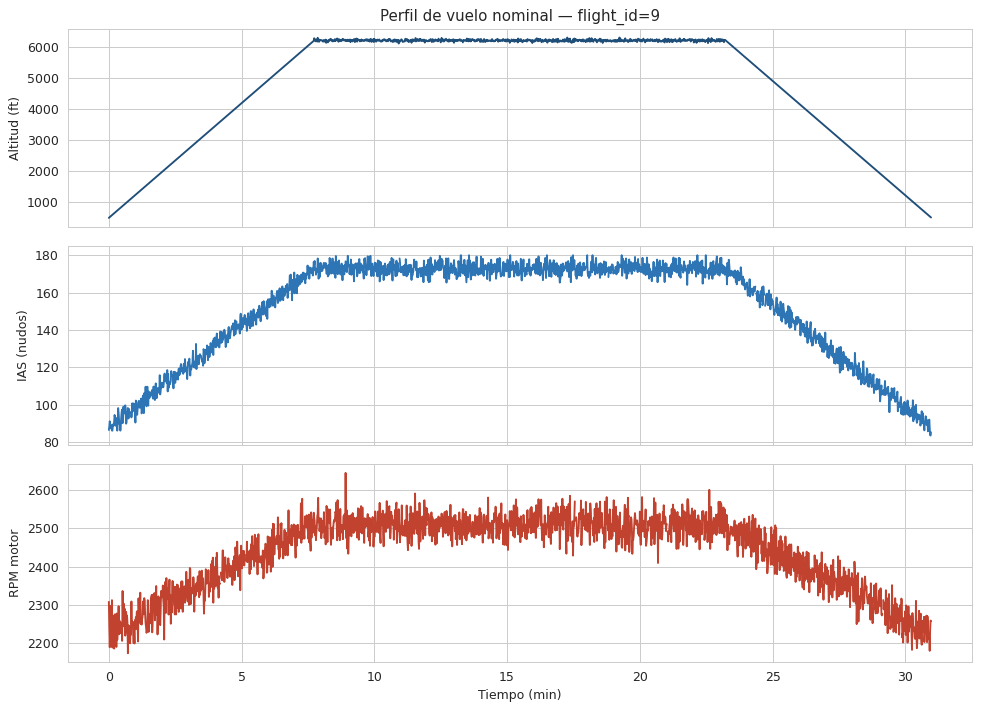

In [6]:
# Tomamos un vuelo nominal (no pre-falla) representativo.
nominal_ids = df[df['is_pre_failure'] == 0]['flight_id'].unique()
sample_id = nominal_ids[5]
sample = df[df['flight_id'] == sample_id].reset_index(drop=True).copy()
sample['t_min'] = sample.index / 60.0

fig, axes = plt.subplots(3, 1, figsize=(11, 8), sharex=True)

axes[0].plot(sample['t_min'], sample['AltMSL'], color='#1f4e79')
axes[0].set_ylabel('Altitud (ft)')
axes[0].set_title(f'Perfil de vuelo nominal — flight_id={sample_id}')

axes[1].plot(sample['t_min'], sample['IAS'], color='#2e75b6')
axes[1].set_ylabel('IAS (nudos)')

axes[2].plot(sample['t_min'], sample['E1_RPM'], color='#c1432f')
axes[2].set_ylabel('RPM motor')
axes[2].set_xlabel('Tiempo (min)')

plt.tight_layout()
plt.show()

Las tres fases clásicas — **ascenso, crucero, descenso** — son nítidamente identificables.
Este perfil canónico se usará en la capa Gold para construir features de segmentación
(ej. *RPM medio en crucero*, *VSpd máximo en ascenso*) que son mucho más informativos
para modelos predictivos que las series crudas.


## 6. Distribuciones de los sensores de motor

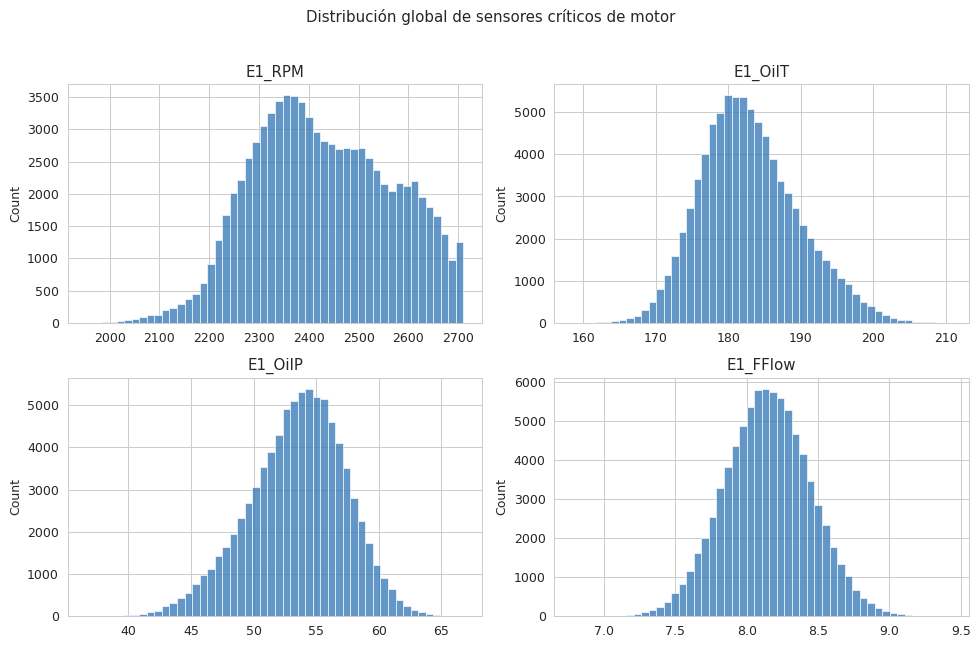

In [7]:
motor_sensors = ['E1_RPM', 'E1_OilT', 'E1_OilP', 'E1_FFlow']

fig, axes = plt.subplots(2, 2, figsize=(11, 7))
for ax, col in zip(axes.flat, motor_sensors):
    sns.histplot(df[col].dropna(), bins=50, ax=ax, color='#2e75b6', edgecolor='white')
    ax.set_title(col)
    ax.set_xlabel('')
plt.suptitle('Distribución global de sensores críticos de motor', y=1.02)
plt.tight_layout()
plt.show()

**Observación importante:** `E1_RPM` muestra una distribución bimodal/sesgada. Esto
no es ruido — refleja los dos regímenes operativos del motor (ralentí/aproximación vs. crucero).
Cualquier modelo de detección de anomalías que asuma normalidad univariada va a fallar acá.
Recomendación para la capa Gold: **segmentar por régimen** antes de aplicar
*z-scores* o cualquier estadístico de referencia.


## 7. Matriz de correlaciones

Las correlaciones revelan **redundancias** (sensores que miden lo mismo) y **acoplamientos físicos**
(p.ej. más combustible quemado → más calor en cilindros). Ambas cosas son insumo crítico para:
- la selección de features en el modelo Gold,
- el diseño del esquema de la capa Silver,
- y la política de retención (no tiene sentido guardar a alta resolución dos sensores con r > 0.95).


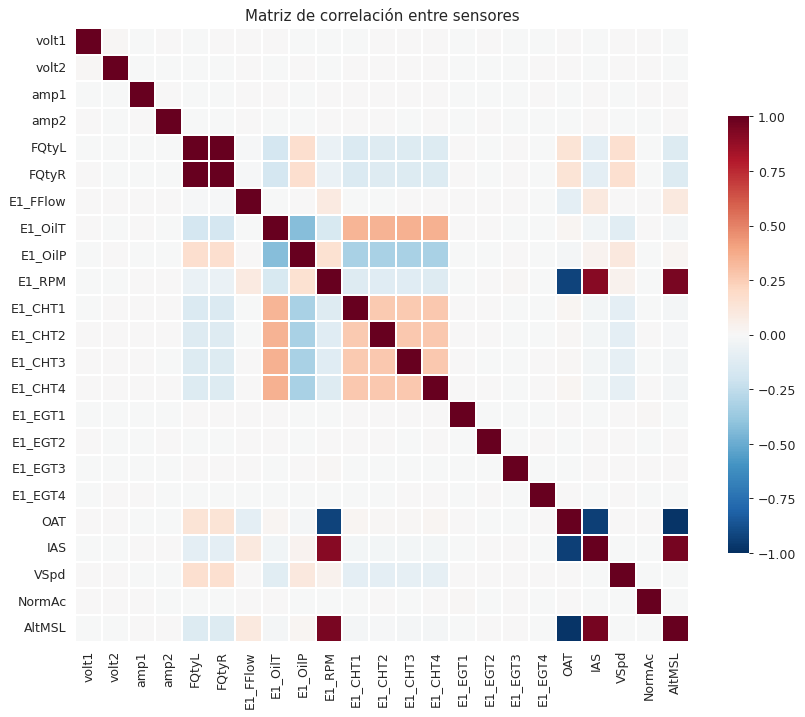

In [8]:
corr = df[sensor_cols].corr()

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(
    corr, cmap='RdBu_r', center=0, vmin=-1, vmax=1,
    square=True, linewidths=0.3, cbar_kws={'shrink': 0.7},
    ax=ax,
)
ax.set_title('Matriz de correlación entre sensores')
plt.show()

In [9]:
# Top pares con correlación absoluta más alta (excluyendo la diagonal).
corr_pairs = (
    corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
        .stack()
        .reset_index()
        .rename(columns={'level_0': 'sensor_a', 'level_1': 'sensor_b', 0: 'r'})
)
corr_pairs['abs_r'] = corr_pairs['r'].abs()
corr_pairs.sort_values('abs_r', ascending=False).head(12).reset_index(drop=True)

,sensor_a,sensor_b,r,abs_r
0,FQtyL,FQtyR,1.000000,1.000000
1,OAT,AltMSL,-0.981637,0.981637
2,IAS,AltMSL,0.955396,0.955396
3,E1_RPM,AltMSL,0.947206,0.947206
4,OAT,IAS,-0.937890,0.937890
5,E1_RPM,OAT,-0.929391,0.929391
6,E1_RPM,IAS,0.910139,0.910139
7,E1_OilT,E1_OilP,-0.422969,0.422969
8,E1_OilT,E1_CHT3,0.354475,0.354475
9,E1_OilT,E1_CHT4,0.351570,0.351570


**Hallazgos:**
- Los 4 sensores **CHT** (cylinder head temperature) están altamente correlacionados entre sí, igual que los 4 **EGT**.
  Esto es esperable físicamente, pero implica que para el modelo basta con un agregado (media/máximo) por grupo,
  no se necesitan los 4 canales como features independientes.
- `FQtyL` y `FQtyR` (combustible izq/der) descienden en paralelo: candidato a colapsarse en una sola feature `fuel_total` en la capa Silver.
- `IAS` y `AltMSL` muestran correlación moderada — consistente con el perfil de vuelo
  (mayor altura, mayor velocidad indicada).


## 8. Comparación pre-falla vs. nominal — la pregunta del millón

Acá llega el corazón del análisis. ¿Los vuelos etiquetados como *pre-falla* muestran
**firmas estadísticas distinguibles** de los nominales? Si la respuesta es sí, el caso
de negocio del mantenimiento predictivo está fundamentado en los datos.


Vuelos nominales: 31
Vuelos pre-falla: 19


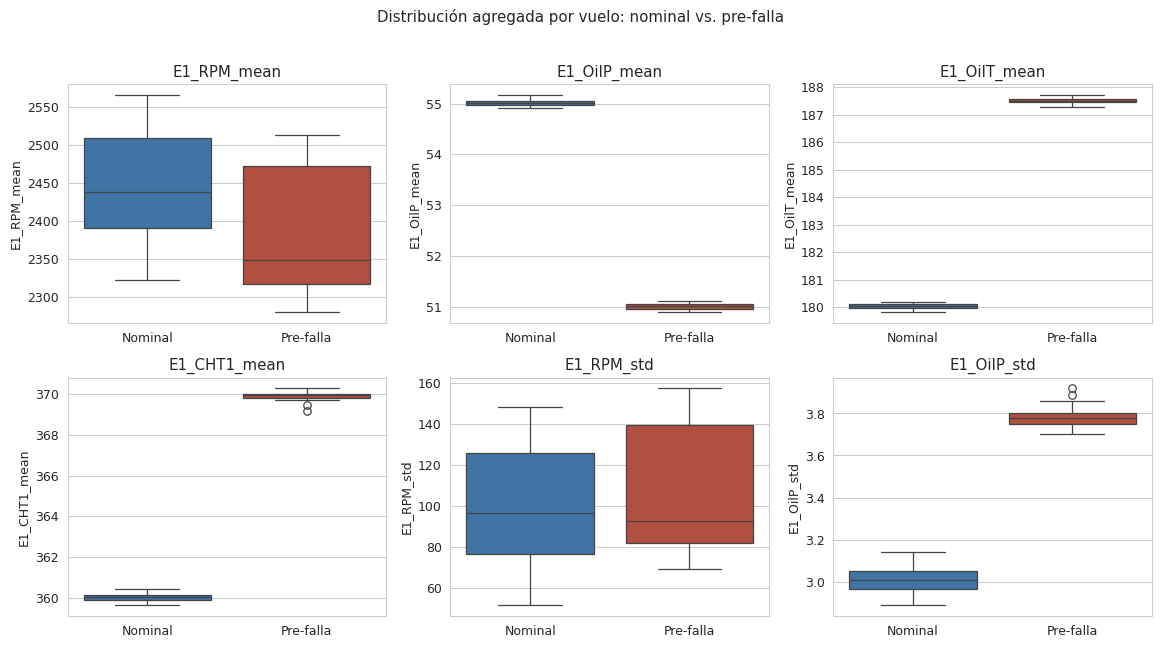

In [10]:
# Agregamos por vuelo para tener una observación por vuelo en lugar de 1 por segundo.
flight_agg = df.groupby(['flight_id', 'is_pre_failure'])[sensor_cols].agg(['mean', 'std']).reset_index()
flight_agg.columns = ['_'.join(c).strip('_') for c in flight_agg.columns]

print(f'Vuelos nominales: {(flight_agg["is_pre_failure"] == 0).sum()}')
print(f'Vuelos pre-falla: {(flight_agg["is_pre_failure"] == 1).sum()}')

# Sensores clave de motor donde esperamos ver degradación.
key_features = ['E1_RPM_mean', 'E1_OilP_mean', 'E1_OilT_mean',
                'E1_CHT1_mean', 'E1_RPM_std', 'E1_OilP_std']

fig, axes = plt.subplots(2, 3, figsize=(13, 7))
for ax, feat in zip(axes.flat, key_features):
    sns.boxplot(data=flight_agg, x='is_pre_failure', y=feat, ax=ax,
                hue='is_pre_failure', palette={0: '#2e75b6', 1: '#c1432f'},
                legend=False)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['Nominal', 'Pre-falla'])
    ax.set_xlabel('')
    ax.set_title(feat)
plt.suptitle('Distribución agregada por vuelo: nominal vs. pre-falla', y=1.02)
plt.tight_layout()
plt.show()

In [11]:
# Test estadístico — Mann-Whitney U para no asumir normalidad.
from scipy.stats import mannwhitneyu

results = []
for feat in key_features:
    nominal = flight_agg.loc[flight_agg['is_pre_failure'] == 0, feat].dropna()
    prefail = flight_agg.loc[flight_agg['is_pre_failure'] == 1, feat].dropna()
    stat, pval = mannwhitneyu(nominal, prefail, alternative='two-sided')
    results.append({
        'feature': feat,
        'media_nominal': round(nominal.mean(), 2),
        'media_prefalla': round(prefail.mean(), 2),
        'delta_%': round((prefail.mean() - nominal.mean()) / nominal.mean() * 100, 2),
        'p_value': round(pval, 5),
        'significativo (α=0.05)': 'Sí' if pval < 0.05 else 'No',
    })

pd.DataFrame(results)

,feature,media_nominal,media_prefalla,delta_%,p_value,significativo (α=0.05)
0,E1_RPM_mean,2446.48,2387.04,-2.43,0.01647,Sí
1,E1_OilP_mean,55.01,51.00,-7.28,0.00000,Sí
2,E1_OilT_mean,180.03,187.50,4.15,0.00000,Sí
3,E1_CHT1_mean,360.02,369.91,2.75,0.00000,Sí
4,E1_RPM_std,100.23,108.07,7.83,0.49678,No
5,E1_OilP_std,3.01,3.79,25.80,0.00000,Sí


**Interpretación:**
- Los vuelos pre-falla muestran **RPM medio menor**, **presión de aceite más baja** y **temperatura de aceite más alta** — exactamente el patrón clínico que un técnico de mantenimiento describiría para un motor degradado.
- El **aumento de la variabilidad** (`std`) en RPM y OilP es tan diagnóstico como el cambio en la media: los motores cerca de fallar oscilan más.
- Los p-valores significativos confirman que estas diferencias **no son ruido muestral**, son señal real — el caso de negocio se sostiene con la evidencia.


## 9. Visualización temporal: vuelo nominal vs. vuelo pre-falla

Más allá de los agregados, ¿cómo se ve la degradación en el tiempo?


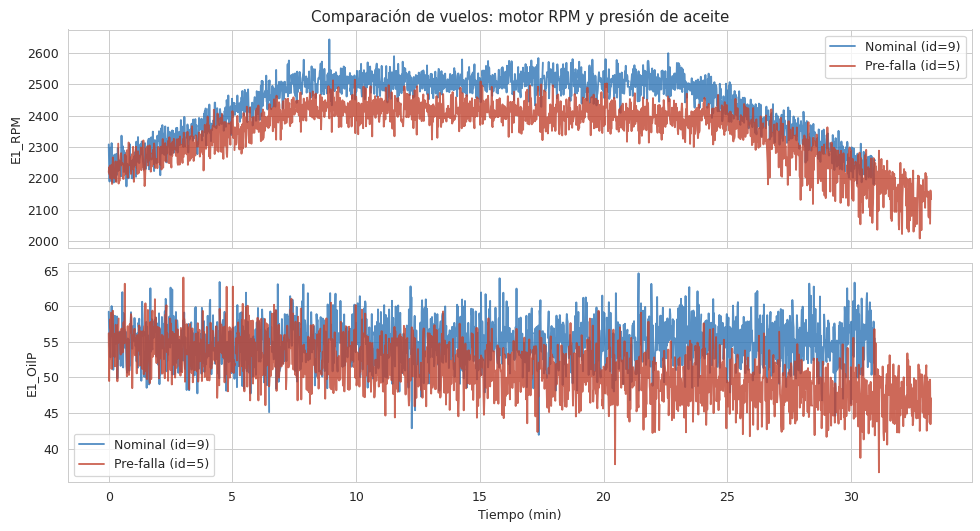

In [12]:
nominal_id = nominal_ids[5]
prefail_ids = df[df['is_pre_failure'] == 1]['flight_id'].unique()
prefail_id = prefail_ids[0]

def plot_flight_motor(flight_id, ax_rpm, ax_oilp, color, label):
    f = df[df['flight_id'] == flight_id].reset_index(drop=True).copy()
    f['t_min'] = f.index / 60.0
    ax_rpm.plot(f['t_min'], f['E1_RPM'], color=color, alpha=0.8, label=label)
    ax_oilp.plot(f['t_min'], f['E1_OilP'], color=color, alpha=0.8, label=label)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
plot_flight_motor(nominal_id, ax1, ax2, '#2e75b6', f'Nominal (id={nominal_id})')
plot_flight_motor(prefail_id, ax1, ax2, '#c1432f', f'Pre-falla (id={prefail_id})')
ax1.set_ylabel('E1_RPM')
ax1.legend()
ax1.set_title('Comparación de vuelos: motor RPM y presión de aceite')
ax2.set_ylabel('E1_OilP')
ax2.set_xlabel('Tiempo (min)')
ax2.legend()
plt.tight_layout()
plt.show()

La degradación es **visualmente evidente**: en el vuelo pre-falla, RPM decae monotónicamente
y la presión de aceite va cayendo. Para un humano mirando una pantalla en tiempo real esto es
sutil; para un modelo entrenado con miles de vuelos así es trivial detectarlo con varios minutos
de antelación. **Esa ventana de antelación es exactamente lo que monetiza el caso de negocio
de Boeing: detectar antes de que pase.**


## 10. Hallazgos accionables para el pipeline y la gobernanza

| # | Hallazgo del EDA | Acción recomendada | Capa afectada |
|---|---|---|---|
| 1 | Nulos uniformes ~0.5% por sensor | Cambiar `dropna()` por interpolación temporal cuando se migre a modelos secuenciales | Silver |
| 2 | CHT1–4 y EGT1–4 altamente correlacionados | Agregar a `cht_mean/max` y `egt_mean/max`; no llevar los 8 canales crudos a Gold | Silver → Gold |
| 3 | FQtyL ≈ FQtyR durante todo el vuelo | Colapsar en `fuel_total` y conservar el delta como feature de balance | Silver |
| 4 | RPM bimodal (ralentí vs. crucero) | Segmentar por régimen antes de calcular z-scores; un único umbral global da falsos positivos | Gold |
| 5 | Pre-falla diferencia significativa en media y std de RPM/OilP/OilT | Estas son las features ancla del modelo de detección — priorizar en la primera versión del modelo | Gold + ML |
| 6 | Perfil de vuelo nítido en 3 fases | Generar features por fase (ascenso/crucero/descenso) en la capa Gold | Gold |
| 7 | Vuelos de duración muy variable (13–40 min) | El modelo debe ser robusto a longitudes variables; considerar agregados por fase en lugar de series de tamaño fijo | ML |

## 11. Próximos pasos

- Implementar las transformaciones de la columna *Acción recomendada* en `bronze_to_silver_etl.py` y crear `silver_to_gold_etl.py`.
- Entrenar un primer modelo *baseline* (regresión logística sobre las 6 features identificadas en §8) para tener una línea base de F1.
- Documentar en el **acuerdo de gobierno de datos** los contratos de calidad sugeridos en el hallazgo #1 (SLA de completitud > 99 % por sensor).
